In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import os
from hubble import hubble_fit
from hubble.hubble_fit import *
from hubble.hubble_utils import *
from hubble.hubble_likelihood import *
from hubble.hubble_plotting import *
from hubble.hubble_model import *
from hubble.hubble_completeness_refactored import *

CPU Num Cores: 6


In [2]:
from hubble.completeness_mock_catalog import (
    COSMO,
    build_shen_lf,
    mock_m_per_zbin,
    save_mock_catalog,
)

In [3]:
# ----------------------------
# Load Pantheon
# ----------------------------
df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = hubble_fit.load_pantheon_data()


# --------------------------------------------------
# 1. Load AGN sample
# --------------------------------------------------
lc_fitting_results_file = "../data/results/data/nov10a_single_chisq_carma_mixscalar_nozband_highertaufastlim_removemix_fixband_lagblrband_chisq_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4.h5"
spectra_fitting_results_file = "../data/results/data/jaxqsofit_mar15c.csv"

df_agn, df_agn_all = load_agn_data(
    lc_fitting_results_file,
    only_load=False,
    fhost_cut=10,
    spectra_fit_csv=[spectra_fitting_results_file],
    correct_sigma_uv_host=False,
    pickled=True,
)

# --------------------------------------------------
# 2. Generate Hopkins mock catalog
# --------------------------------------------------
phi_log10, m_grid, z_bins = build_shen_lf(None)

rng = np.random.default_rng(123)
_, nexp, _, nsel, z_all, m_all, m_2500_all, bin_index = mock_m_per_zbin(
    phi_log10,
    m_grid,
    z_bins,
    area_deg2=5.0,
    alpha_nu=-0.5,
    dalpha_nu=0.3,
    cosmo=COSMO,
    z_res=512,
    m_scatter=0.0,
    kcorr_zref=2.0,
    m_lim=28.0,
    rng=rng,
    return_z=True,
    return_global=True,
    verbose=True,
)

sim_file = "../data/mock_mag_z_hopkins.h5"
save_mock_catalog(sim_file, z_all, m_all, m_2500_all, m_limit=28.0)
print(f"Saved mock catalog: {sim_file}")
print(f"Generated {len(z_all)} mock sources before final save cut.")

# --------------------------------------------------
# 3. Build completeness map from that mock
# --------------------------------------------------
completeness2d, mag_centers, z_centers, dm, dz, sigma_mag = get_completeness_function_2d(
    df_agn,
    sim_file=sim_file,
    n_mag_bins=30,
    n_z_bins=40,
    smooth_counts=True,
    plot=True,
    fill_along_mag=False,
    fill_along_z=False,
)

print("Completeness sim file:", sim_file)
print("mag grid:", mag_centers.shape, mag_centers.min(), mag_centers.max())
print("z grid:", z_centers.shape, z_centers.min(), z_centers.max())
print("sigma_mag used:", sigma_mag)

Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).
Number of quasars loaded: 13090
Populating spectra fit data from: ['/Users/colinburke/research/qvc/data/results/data/jaxqsofit_mar15c.csv']
Loading spectra fit CSV (1/1): /Users/colinburke/research/qvc/data/results/data/jaxqsofit_mar15c.csv
Length of merged DataFrame (best=True): 13090
Cut on apparent_mag_2500 : 222 objects removed
Matched 294 out of 12868 objects to CSC3 catalog.
Populating LC info from: /Users/colinburke/research/qvc/data/aug4_sample_chisqg10_ebv005sn3_lcdata.csv
Length of lc info merged DataFrame: 12868
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 3092
Number of quasars with z > 3: 399
Highest redshift quasar: 4.455935435869128
Excluding 1 objects by exclusion list
Cut on tau vs sigma diagram: 168 objects removed
Removed 91 objects with len_dropped_bands == 4 or 5
BLR amplitude cut log_amp_delta

In [ ]:
# ----------------------------
# Run joint AGN+SN fit
# ----------------------------
r = hubble_fit.run_single(
    df_agn=df_agn,
    df_agn_all=df_agn_all,
    df_pantheon=df_pantheon,
    _sna_L=_sna_L,
    _sna_Lower=_sna_Lower,
    _sna_LogdetCov=_sna_LogdetCov,
    cosmo_model="Flatw0waCDM",
    completeness=True,
    completeness_sim_file=sim_file,
    use_full_cov=True,
    speed="fast",                  # try "test" first if you want a lighter run
    only_sna=False,
    skip_plots=False,
    )

Saving plots to  plots/hubble/shen_completeness_test/Flatw0waCDM_joint_fast_all_z0p44_3p16
Completeness enabled with mock catalog file: ../data/mock_mag_z_hopkins.h5

AGN pivot summary
--------------------------------------------------------------------
Quantity       Type                 log10 value    linear value
sigma_UV       computed mean            -0.7392          0.1823
tau_UV_RF      computed mean             2.7196        524.2890
sigma_UV       fixed pivot              -0.6990          0.2000
tau_UV_RF      fixed pivot               2.6990        500.0000
Running sampling with 9 parameters for cosmological model: Flatw0waCDM
Building completeness map using mock catalog: ../data/mock_mag_z_hopkins.h5
Smoothing counts with sigma_mag=0.2 mag (sigma_mag/dm=1.0909090909091106), sigma_z=0.2 absolute z
Checkpoint file: results/hubble_posteriors/shen_completeness_test/posteriors_Flatw0waCDM_joint_fast_all_z0p44_3p16.h5
Starting Hubble Fit with 8500 AGNs and 1657 SNes...
[Warning] S

175it [03:31,  1.06s/it, batch: 0 | bound: 21 | nc: 58 | ncall: 4071 | eff(%):  4.278 | loglstar:   -inf < -7522.186 <    inf | logz: -7534.423 +/-  0.766 | dlogz: 475.757 > 10.000]

Using linear-z bins: [0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4]
Note: 9 / 8715 AGN clipped in residuals panel (> 3σ)
Plotting binned AGN (linear z) at: [0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3 2.5 2.7 2.9 3.1 3.3]
	mask_out: [False False False False False False False False False False False False
 False False  True]


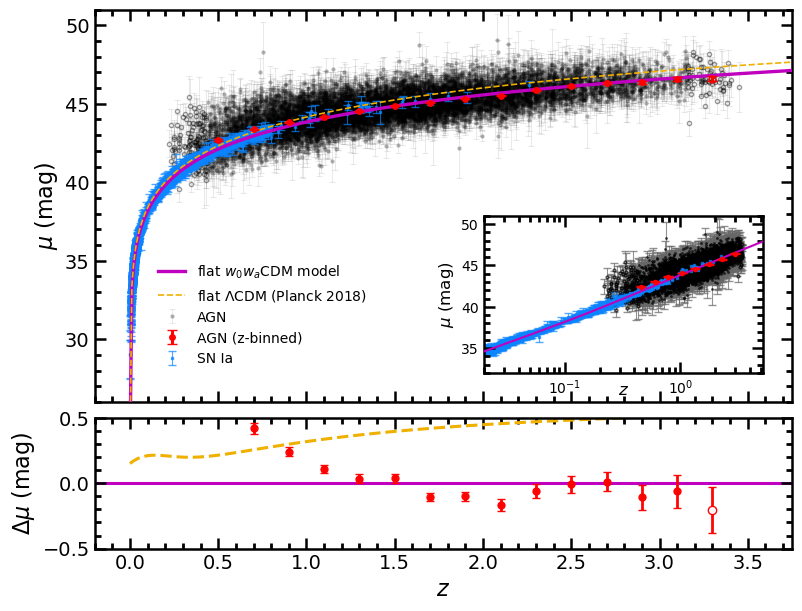

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4 (sorted by residual, largest last):
	z: 0.33 | object_id: 1414541 | npca_qso: N/A | SDSS: 013508.75+011450.0 | RA: 23.78646 | DEC: 1.24724 | Residual: 4.4
	z: 0.75 | object_id: 1440679 | npca_qso: N/A | SDSS: 001348.15-003541.5 | RA: 3.45065 | DEC: -0.59488 | Residual: 5.1
Residuals saved to plots/hubble/shen_completeness_test/Flatw0waCDM_joint_fast_all_z0p44_3p16/residuals.csv
Outliers (|residuals| > 5) saved to plots/hubble/shen_completeness_test/Flatw0waCDM_joint_fast_all_z0p44_3p16/outliers.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with mu_pred_std > 4:
	z: 0.33 | object_id: 1414541 | npca_qso: N/A | SDSS: 013508.75+011450.0 | RA: 23.78646 | DEC: 1.24724 | Residual: 4.4
	z: 0.75 | object_id: 1440679 | npca_qso: N/A | SDSS: 001348.15-003541.5 | RA: 3.45065 | DEC: -0.59488 | Residual: 5.1


(array([ 1.27528119, -0.84435706,  0.00224987, ...,  0.56841471,
         1.64910532,  0.30607757], shape=(8715,)),
 array([1.01670875, 0.93943695, 1.14686963, ..., 0.98799294, 1.09702589,
        1.26347314], shape=(8715,)),
 array([46.02610106, 42.75789423, 46.81863345, ..., 44.59751202,
        44.17868416, 44.91285977], shape=(8715,)),
 array([0.57907729, 0.42915686, 0.78545768, ..., 0.52703308, 0.71070361,
        0.94762767], shape=(8715,)),
 array([1.01670875, 0.93943695, 1.14686963, ..., 0.98799294, 1.09702589,
        1.26347314], shape=(8715,)))

In [ ]:
(
    flat_samples,
    model_labels,
    dm_interp,
    logZ,
    logZerr,
    debiased_residuals,
    age,
    age_err,
) = r

run_tag = hubble_fit.make_run_tag(
    cosmo_model="Flatw0waCDM",
    only_sna=False,
    speed="fast",      # match the value you used in run_single
    N=None,
    z_range=(0.44, 3.16),
)

hubble_fit.plot_hubble(
    flat_samples,
    df_agn,
    df_pantheon,
    cosmo_model="Flatw0waCDM",
    z_pivot_agn=hubble_fit.z_pivot_agn,
    show_true=False,
    show=True,
    debias=True,
    dm_interp=dm_interp,
    verbose=True,
)
